In [12]:
print("Dataset Source**: [ Energy Crude Oil Tweets](https://www.kaggle.com/datasets/yassinehamdaoui1/sentiment-analysis-in-energy-crude-oil")
print("I will use only the text column so i use as input to unsupervised algorithms like LDA, which will automatically discover the hidden themes (topics) in the tweets.")

Dataset Source**: [ Energy Crude Oil Tweets](https://www.kaggle.com/datasets/yassinehamdaoui1/sentiment-analysis-in-energy-crude-oil
I will use only the text column so i use as input to unsupervised algorithms like LDA, which will automatically discover the hidden themes (topics) in the tweets.


In [25]:
import pandas as pd
df = pd.read_csv("tweets.csv")
print("Dataset contains " , len(df))

Dataset contains  1000


In [ ]:
import tweepy

bearer_token = "AAAAAAAAAAAAAAAAAAAAAC1D3AEAAAAAJEnPUJnxRrzSM%2FRh0Uk%2FGY3foaI%3DNs9gVNZgPIa62G9B4gAhk6JmO16bh8vjTjKjjmA8rXhgHlFUzg"

client = tweepy.Client(bearer_token=bearer_token)

query = "(oil OR energy) prices politics inflation lang:en -is:retweet"

response = client.search_recent_tweets(query=query, max_results=10)

if response.data:
    for tweet in response.data:
        print(tweet.text)
else:
    print("No tweets found for this query.")


@Zacklol33 @GOP Not blatant lies, but selective spin. PPI was flat in June (no producer inflation), core CPI was 2.9% (below 3% expected), wages rose 0.2% monthly. Gas prices fluctuated but averaged higher than Jan; energy up 0.9% in June. Politics often credits leaders for trends. Sources: BLS,
🇬🇧 Reeves Blamed For UK Inflation Hike, As NI Rise Hits Food Prices

▫Labour MPs are urging action on energy bills
▫@callumcmason @whazell
▫https://t.co/pdwux2q2vJ

#frontpagestoday #UK @theipaper https://t.co/eyi1R5Edxj
Trump: "We've had very little inflation." The facts:  Inflation was 2.7 percent, as the impact of taxes on imports showed at checkout. Housing, food, energy, apparel, and household furnishings prices also reported sizable gains. https://t.co/LjwpOhnTAV https://t.co/0bvSfw46Md
@catturd2 Inflation in 2025 reflects persistent Trump-era tariffs, global supply disruptions, and energy volatility. Powell’s Fed is acting on data to stabilize prices—not politics. Blaming ‘TDS’ is pure d

In [3]:
tweets_10 = [
    "@Zacklol33 @GOP Not blatant lies, but selective spin. PPI was flat in June (no producer inflation), core CPI was 2.9% (below 3% expected), wages rose 0.2% monthly. Gas prices fluctuated but averaged higher than Jan; energy up 0.9% in June. Politics often credits leaders for trends. Sources: BLS,",
    "🇬🇧 Reeves Blamed For UK Inflation Hike, As NI Rise Hits Food Prices",
    "▫Labour MPs are urging action on energy bills",
    "▫@callumcmason @whazell",
    "▫https://t.co/pdwux2q2vJ",
    "#frontpagestoday #UK @theipaper https://t.co/eyi1R5Edxj",
    "Trump: \"We've had very little inflation.\" The facts:  Inflation was 2.7 percent, as the impact of taxes on imports showed at checkout. Housing, food, energy, apparel, and household furnishings prices also reported sizable gains. https://t.co/LjwpOhnTAV https://t.co/0bvSfw46Md",
    "@catturd2 Inflation in 2025 reflects persistent Trump-era tariffs, global supply disruptions, and energy volatility. Powell’s Fed is acting on data to stabilize prices—not politics. Blaming ‘TDS’ is pure deflection.",
    "@AnuarSaddat Politics aside I think its not about the finance bill but rather largely due to the economic effects conflict between Israel and Iran which pushed the global oil prices around this period. But the shift is sharp and may push inflation up if not brought down in the coming months.",
    "https://t.co/zfBzM9Mmei"
]


In [4]:
import csv

with open('first_10_tweets.csv', mode='w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(['Tweet'])
    for tweet in tweets_10:
        writer.writerow([tweet])

print("Manually saved 10 tweets to 'first_10_tweets.csv'")


Manually saved 10 tweets to 'first_10_tweets.csv'


In [ ]:
import tweepy
import csv

bearer_token = "AAAAAAAAAAAAAAAAAAAAAC1D3AEAAAAAJEnPUJnxRrzSM%2FRh0Uk%2FGY3foaI%3DNs9gVNZgPIa62G9B4gAhk6JmO16bh8vjTjKjjmA8rXhgHlFUzg"
client = tweepy.Client(bearer_token=bearer_token)


query = "(oil OR energy) (prices OR inflation OR politics) lang:en -is:retweet"

response = client.search_recent_tweets(query=query, max_results=90)

if response.data:
    with open('tweets_90.csv', mode='w', newline='', encoding='utf-8') as file:
        writer = csv.writer(file)
        writer.writerow(['Tweet'])
        for tweet in response.data:
            writer.writerow([tweet.text])
    print(f"✅ Saved {len(response.data)} tweets to 'tweets_90.csv'")
else:
    print("⚠️ No tweets found.")

✅ Saved 90 tweets to 'tweets_90.csv'


In [18]:
import pandas as pd

df1 = pd.read_csv("first_10_tweets.csv")
df2 = pd.read_csv("tweets_90.csv")

merged_df = pd.concat([df1, df2], ignore_index=True)
merged_df.to_csv("all_100_tweets.csv", index=False)

print("✅ Merged and saved as 'all_100_tweets.csv'")


✅ Merged and saved as 'all_100_tweets.csv'


In [7]:
import re
df = pd.read_csv("all_100_tweets.csv")

def clean_tweet(text):
    text = re.sub(r'http\S+', '', text)              
    text = re.sub(r'@\w+', '', text)                 
    text = re.sub(r'#\w+', '', text)                 
    text = re.sub(r'[^\w\s]', '', text)            
    return text.lower()

df['Cleaned_Tweet'] = df['Tweet'].apply(clean_tweet)
df[['Cleaned_Tweet']].to_csv("cleaned_tweets.csv", index=False)

In [9]:
df_new = pd.read_csv("cleaned_tweets.csv")
print(df_new.head(15))

                                        Cleaned_Tweet
0     not blatant lies but selective spin ppi was ...
1    reeves blamed for uk inflation hike as ni ris...
2        labour mps are urging action on energy bills
3                                                 NaN
4   trump weve had very little inflation the facts...
5    inflation in 2025 reflects persistent trumper...
6    politics aside i think its not about the fina...
7                                                 NaN
8   trump admin rebuffs schiff reopening massive p...
9   trump admin rebuffs schiff reopening massive p...
10   come on commies\nwe cant let good things like...
11    tariffs do act as a tax on consumers by rais...
12              yes crippling energy prices and taxes
13   ryyyt wait for the tariffs to sink in real de...
14   whats wrong is the commitment of buying energ...


In [10]:
df_new=df_new.dropna()
print(df_new.head(15))

                                        Cleaned_Tweet
0     not blatant lies but selective spin ppi was ...
1    reeves blamed for uk inflation hike as ni ris...
2        labour mps are urging action on energy bills
4   trump weve had very little inflation the facts...
5    inflation in 2025 reflects persistent trumper...
6    politics aside i think its not about the fina...
8   trump admin rebuffs schiff reopening massive p...
9   trump admin rebuffs schiff reopening massive p...
10   come on commies\nwe cant let good things like...
11    tariffs do act as a tax on consumers by rais...
12              yes crippling energy prices and taxes
13   ryyyt wait for the tariffs to sink in real de...
14   whats wrong is the commitment of buying energ...
15  trump admin rebuffs schiff reopening massive p...
16   government amp political mps like yourself pr...


In [3]:
from transformers import pipeline

c:\Users\hamza\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [ ]:
import torch
print(torch.__version__)
print(torch.rand(2, 2))  


2.7.1+cpu
tensor([[0.4434, 0.0981],
        [0.2869, 0.4630]])


In [2]:
from transformers import pipeline

generator = pipeline("text-generation", model="gpt2")

def generate_tweets(prompt, num_tweets=10):
    return generator(prompt, max_length=50, num_return_sequences=num_tweets)

prompt = "Write a tweet about oil or energy and how it relates to prices, inflation, or politics."
synthetic_tweets = generate_tweets(prompt, 10)

for tweet in synthetic_tweets:
    print(tweet["generated_text"])



c:\Users\hamza\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
c:\Users\hamza\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\hamza\.cache\huggingface\hub\models--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` 

Write a tweet about oil or energy and how it relates to prices, inflation, or politics. You can reach me at michael@washpost.com or follow me on twitter at @peter_michael.
Write a tweet about oil or energy and how it relates to prices, inflation, or politics. Follow us on Twitter @thedailybeast, or sign up to our daily email to get the latest energy and environment news from The Daily Caller News Foundation.
Write a tweet about oil or energy and how it relates to prices, inflation, or politics.

"I think it's pretty simple," said Richard Gervais, chairman of the London-based oil company Royal Dutch Shell. "It's just a matter of being more honest. We've got to stop playing the politics of politics, that's what we're doing now."

He added: "The government has done an excellent job of getting the facts from the media. The government has done an excellent job of getting the facts from the media. The government has done an excellent job of getting the facts from the public about oil prices 

In [ ]:
from transformers import pipeline
import pandas as pd
import time

generator = pipeline("text-generation", model="gpt2")

def generate_tweets(prompt, num_tweets=100, batch_size=10):
    tweets = []
    for _ in range(num_tweets // batch_size):
        try:
            results = generator(prompt, max_length=50, num_return_sequences=batch_size)
            tweets.extend([tweet['generated_text'] for tweet in results])
        except Exception as e:
            print("Error:", e)
        time.sleep(1)  
    return tweets


prompt = "Write a tweet about oil or energy and how it relates to prices, inflation, or politics."

synthetic_tweets = generate_tweets(prompt, num_tweets=10000, batch_size=10)


df = pd.DataFrame(synthetic_tweets, columns=['tweet'])
df.to_csv('synthetic_tweets.csv', index=False)

print("Saved 10,000 tweets to synthetic_tweets.csv")


c:\Users\hamza\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Device set to use cpu
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Settin

Saved 10,000 tweets to synthetic_tweets.csv


In [ ]:
import pandas as pd

df_cleaned = pd.read_csv("all_100_tweets.csv")
df_cleaned.columns = ['tweet']  

df_tweets = pd.read_csv("tweets.csv")
df_tweets = df_tweets[['text']].rename(columns={'text': 'tweet'}) 
df_combined = pd.concat([df_cleaned, df_tweets], ignore_index=True)
df_combined = df_combined.dropna()
df_combined.to_csv("combined_tweets.csv", index=False)

print("✅ Combined dataset saved as combined_tweets.csv")



✅ Combined dataset saved as combined_tweets.csv


In [10]:
import pandas as pd
from collections import Counter

df1 = pd.read_csv("combined_tweets.csv")

words = " ".join(df1["tweet"].astype(str)).lower().split()
top3 = Counter(words).most_common(3)

print(top3)


[('the', 538), ('rt', 535), ('#crudeoil', 441)]


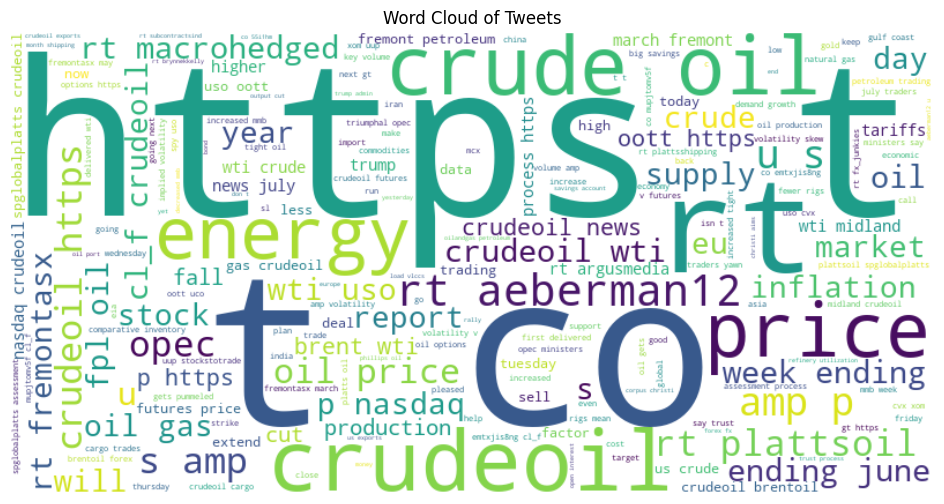

In [16]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df1["tweet"].astype(str).tolist()).lower()
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

text = " ".join(df1["tweet"].astype(str).tolist()).lower()
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Tweets")
plt.show()

In [11]:
df1['tweet'] = df1['tweet'].str.lower()


In [60]:
import re

def clean_text(text):
    text = re.sub(r"http\S+|www\S+", "", text)      
    text = re.sub(r"@\w+", "", text)                
    text = re.sub(r"#\w+", "", text)                
    text = re.sub(r"[^a-z\s]", "", text)            
    return text

df1['tweet'] = df1['tweet'].apply(clean_text)


In [ ]:
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def preprocess(text):
    
    tokens = word_tokenize(text)
    pos_tags = pos_tag(tokens)

    
    lemmatized = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in pos_tags]

   
    cleaned = [word for word in lemmatized if word not in stop_words]

    return " ".join(cleaned)


df1['tweet'] = df1['tweet'].apply(preprocess)


In [64]:
df1 = df1[df1['tweet'].str.strip().astype(bool)]

In [68]:
df1.to_csv("finalpreprocessed_tweets.csv", index=False)
print("it was saved"
)

it was saved


In [40]:
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')  
nltk.download('averaged_perceptron_tagger_eng')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hamza\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hamza\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\hamza\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\hamza\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\hamza\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


True

In [ ]:
import pandas as pd
 
df = pd.read_csv("finalpreprocessed_tweets.csv")


In [11]:
import sys
print(sys.executable)


c:\Users\hamza\AppData\Local\Programs\Python\Python312\python.exe


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd 
df=pd.read_csv("finalpreprocessed_tweets.csv")

docs = df['tweet'].tolist()

vectorizer = CountVectorizer(
    min_df=5,         
    max_df=0.4,        
    ngram_range=(1,2) 
)
X_count = vectorizer.fit_transform(docs)
vocab = vectorizer.get_feature_names_out()

print("Matrix shape:", X_count.shape)  
print("Vocab size:", len(vocab))


Matrix shape: (1091, 983)
Vocab size: 983


In [ ]:
from sklearn.decomposition import LatentDirichletAllocation as LDA

K = 3
lda3 = LDA(
    n_components=K,
    learning_method='batch',   
    max_iter=30,
    doc_topic_prior=0.1,       
    topic_word_prior=0.01,     
    random_state=42,
    evaluate_every=-1
)

W3 = lda3.fit_transform(X_count)   
H3 = lda3.components_              
vocab = vectorizer.get_feature_names_out()


In [6]:
import numpy as np

def show_topics(H, vocab, topn=15):
    for k, comp in enumerate(H):
        words = [vocab[i] for i in comp.argsort()[-topn:][::-1]]
        print(f"Topic {k}: " + " | ".join(words))

show_topics(H3, vocab, topn=12)


Topic 0: oil | crude | crude oil | price | go | amp | get | oil price | energy | future | petroleum | uso
Topic 1: oil | opec | cut | amp | crude | july | ampp | price | trader | say | open | high
Topic 2: oil | price | week | energy | end | june | increase | mmb | may | wti | week end | end june


In [8]:
import pandas as pd

doc_topic = pd.DataFrame(W3, columns=[f"topic_{i}" for i in range(K)])
doc_topic['dominant_topic'] = doc_topic.idxmax(axis=1).str.replace('topic_', '').astype(int)
out = pd.concat([df.reset_index(drop=True), doc_topic], axis=1)
out.to_csv("tweets_LDA_K3_doc_topics.csv", index=False)
print("Saved: tweets_LDA_K3_doc_topics.csv")


Saved: tweets_LDA_K3_doc_topics.csv


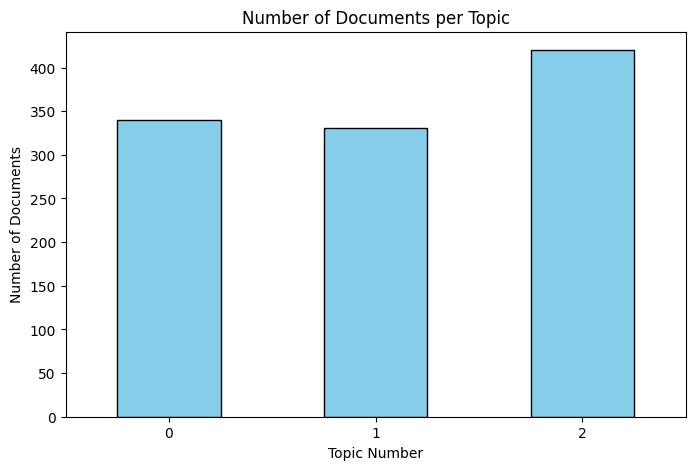

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

tweets = pd.read_csv("tweets_LDA_K3_doc_topics.csv")

topic_counts = tweets['dominant_topic'].value_counts().sort_index()


plt.figure(figsize=(8,5))
topic_counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.xlabel("Topic Number")
plt.ylabel("Number of Documents")
plt.title("Number of Documents per Topic")
plt.xticks(rotation=0)
plt.show()


In [ ]:
import pandas as pd
df = pd.read_csv("tweets_LDA_K3_doc_topics.csv")

topic_cols = ["topic_0", "topic_1", "topic_2"]

df["dominant_topic_id"] = df[topic_cols].idxmax(axis=1)   
df["dominant_topic_id"] = df["dominant_topic_id"].str.extract("(\d+)").astype(int)  # extract number

topic_labels = {
    0: "Energy & Oil Markets",
    1: "Crude Oil Prices",
    2: "OPEC and Petroleum Industry"
}
df["dominant_topic"] = df["dominant_topic_id"].map(topic_labels)

final_df = df[["tweet", "dominant_topic"]]

final_df.to_csv("tweets__topics.csv", index=False)
print("Saved tweet__topics.csv")


Saved tweet__topics.csv


<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
C:\Users\hamza\AppData\Local\Temp\ipykernel_34840\606298194.py:11: SyntaxWarning: invalid escape sequence '\d'
  df["dominant_topic_id"] = df["dominant_topic_id"].str.extract("(\d+)").astype(int)  # extract number


In [26]:
df = pd.read_csv("tweets__topics.csv")
print(df.head())

                                               tweet  \
0  blatant lie selective spin ppi flat june produ...   
1  reef blame uk inflation hike ni rise hit food ...   
2                  labour mp urge action energy bill   
3  trump weve little inflation fact inflation per...   
4  inflation reflect persistent trumpera tariff g...   

                dominant_topic  
0  OPEC and Petroleum Industry  
1             Crude Oil Prices  
2  OPEC and Petroleum Industry  
3             Crude Oil Prices  
4         Energy & Oil Markets  
